In [ ]:
# %% Cell 1: Install Dependencies
!pip install torch torchvision datasets spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [63]:
# Cell 2: Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import spacy
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm



In [64]:
!pip install spacy
import spacy

# Load spaCy's English tokenizer
nlp = spacy.load("en_core_web_sm")

In [66]:
# train_text = load_wikitext('wikitext-2/train.txt')
# valid_text = load_wikitext('wikitext-2/valid.txt')
# test_text = load_wikitext('wikitext-2/test.txt')

def load_wikitext(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    return text

# Now you can use it
train_text = load_wikitext('/content/test.txt')
valid_text = load_wikitext('/content/test.txt')
test_text = load_wikitext('/content/test.txt')

In [110]:
import spacy
import numpy as np
from keras._tf_keras.keras.preprocessing.text import Tokenizer
from keras._tf_keras.keras.preprocessing.sequence import pad_sequences

def tokenize(text, chunk_size=500000):
    tokens = []
    for i in range(0, len(text), chunk_size):
        chunk = text[i:i+chunk_size]
        doc = nlp(chunk)
        tokens.extend([token.text.lower() for token in doc if not token.is_space])
    return tokens

train_tokens = tokenize(train_text)
valid_tokens = tokenize(valid_text)
test_tokens = tokenize(test_text)



# Original vocabulary size (report this)
original_vocab_size = len(tokenizer.word_counts) + 1  # +1 for OOV
print(f"Original Vocabulary Size: {original_vocab_size}")

# Create vocabulary with Tokenizer (limit to 5000 words for Task 1 decoder)
tokenizer = Tokenizer(original_vocab_size, oov_token='<UNK>')
tokenizer.fit_on_texts([train_tokens])
# Convert texts to sequences
train_sequences = tokenizer.texts_to_sequences([train_tokens])[0]
valid_sequences = tokenizer.texts_to_sequences([valid_tokens])[0]
test_sequences = tokenizer.texts_to_sequences([test_tokens])[0]

Original Vocabulary Size: 12044


In [114]:
# Create input-target pairs with sequence length 50
def create_sequences(sequences, seq_length=50):
    inputs, targets = [], []
    for i in range(len(sequences) - seq_length):
        inputs.append(sequences[i:i+seq_length])
        targets.append(sequences[i+seq_length])
    return np.array(inputs), np.array(targets)

In [115]:
X_train, y_train = create_sequences(train_sequences)
X_valid, y_valid = create_sequences(valid_sequences)
X_test, y_test = create_sequences(test_sequences)

In [70]:
# Save processed data
print(X_train.shape)
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_valid.npy', X_valid)
np.save('y_valid.npy', y_valid)
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

(240136, 50)


In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from keras._tf_keras.keras.preprocessing.text import Tokenizer

In [71]:
# Load preprocessed data
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_valid = np.load('X_valid.npy')
y_valid = np.load('y_valid.npy')

In [72]:


import torch

# Convert to PyTorch tensors
train_data = TensorDataset(torch.LongTensor(X_train), torch.LongTensor(y_train))
valid_data = TensorDataset(torch.LongTensor(X_valid), torch.LongTensor(y_valid))

In [113]:


from torch.utils.data import DataLoader

# Assuming 'train_data' and 'valid_data' are defined as in your previous code

batch_size = 64  # Adjust as needed

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)


In [112]:
# prompt: print output shape and target shape

print("Output shape:", train_inputs.shape)
print("Target shape:", train_targets.shape)


Output shape: (36718, 49)
Target shape: (36718, 49)


In [107]:
class EncoderLSTM(nn.Module): # Renamed from LSTMEncoder
    def __init__(self, vocab_size, embed_size=50, hidden_size=100, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, (hidden, cell)

class DecoderLSTM(nn.Module): # Renamed from LSTMDecoder
    def __init__(self, vocab_size, hidden_size=100):
        super().__init__()
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, encoder_outputs):
        # encoder_outputs shape: (batch_size, seq_len, hidden_size)
        return self.fc(encoder_outputs)  # (batch_size, seq_len, vocab_size)

In [116]:
# Model parameters (adjusted based on dataset analysis)
vocab_size = original_vocab_size  # From preprocessing tokenizer
embed_size = 50
hidden_size = 100
num_layers = 2

# Initialize model
# Initialize model
encoder = EncoderLSTM(len(tokenizer.word_index) + 1, embed_size, hidden_size, num_layers)  # Use tokenizer's vocab size
decoder = DecoderLSTM(len(tokenizer.word_index) + 1, hidden_size)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder.to(device)
decoder.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.001)

In [117]:
# Training loop
train_losses = []
num_epochs = 10

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    total_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        # Get encoder outputs and hidden state
        encoder_outputs, (hidden, cell) = encoder(inputs)
        # Pass the hidden state to the decoder
        outputs = decoder(encoder_outputs[:, -1, :])  # Take the last hidden state

        # Calculate loss
        loss = criterion(outputs, targets)  # targets should have shape (batch_size)

        # Backward pass
        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(encoder.parameters(), 5.0)
        nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [1/10], Loss: 5.2579
Epoch [2/10], Loss: 4.7549
Epoch [3/10], Loss: 4.4953
Epoch [4/10], Loss: 4.3055
Epoch [5/10], Loss: 4.1569
Epoch [6/10], Loss: 4.0353
Epoch [7/10], Loss: 3.9299
Epoch [8/10], Loss: 3.8350
Epoch [9/10], Loss: 3.7496
Epoch [10/10], Loss: 3.6710


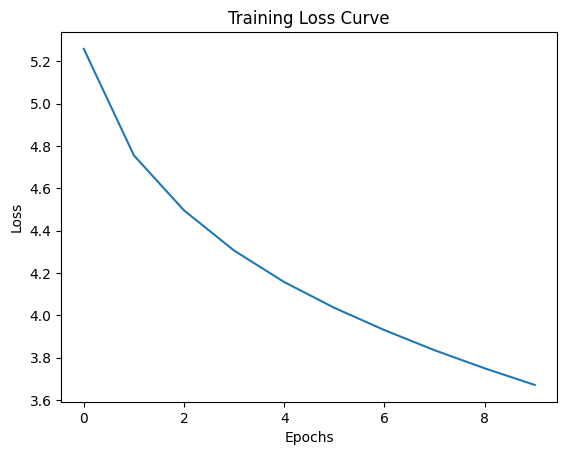

In [120]:
plt.plot(train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Evaluation
encoder.eval()
decoder.eval()
all_preds = []
all_targets = []
total = 0
correct = 0

with torch.no_grad():
    for inputs, targets in valid_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        # Get the encoder outputs and hidden/cell states
        encoder_outputs, (hidden, cell) = encoder(inputs)
        # Pass only the last hidden state to the decoder
        outputs = decoder(encoder_outputs[:, -1, :])  # Take the last hidden state

        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

In [121]:
# Calculate metrics
accuracy = correct / total
perplexity = np.exp(train_losses[-1])
print(f'\nValidation Accuracy: {accuracy:.4f}')
print(f'Validation Perplexity: {perplexity:.4f}')

# Confusion matrix for top 30 errors
cm = confusion_matrix(all_targets, all_preds)
mis_predicted = cm.sum(axis=0) - np.diag(cm)
top_30 = np.argsort(mis_predicted)[-30:]

# Load tokenizer (from preprocessing)
tokenizer = Tokenizer(num_words=5000, oov_token='<UNK>')
tokenizer.word_index = {'<PAD>': 0, '<UNK>': 1}  # Manual setup
tokenizer.index_word = {0: '<PAD>', 1: '<UNK>'}

cm = confusion_matrix(all_targets, all_preds)

# For each class, calculate how often it was incorrectly predicted
mis_predicted = cm.sum(axis=0) - np.diag(cm)
top_30_indices = np.argsort(mis_predicted)[-30:]

# Map indices to words (handle missing keys)
top_30_words = [
    tokenizer.index_word.get(int(i), f'<UNK:{i}>')
    for i in top_30_indices
]

print("Top 30 Mispredicted Words:", top_30_words)

# Gradient analysis
gate_gradients = {'forget': [], 'input': [], 'output': [], 'cell': []}


Validation Accuracy: 0.3307
Validation Perplexity: 39.2928
Top 30 Mispredicted Words: ['<UNK:36>', '<UNK:131>', '<UNK:23>', '<UNK:104>', '<UNK:30>', '<UNK:27>', '<UNK:44>', '<UNK:66>', '<UNK:17>', '<UNK:43>', '<UNK:20>', '<UNK:24>', '<UNK:28>', '<UNK:19>', '<UNK:18>', '<UNK:46>', '<UNK:15>', '<UNK:13>', '<UNK:10>', '<UNK:9>', '<UNK:12>', '<UNK:11>', '<UNK:14>', '<UNK:7>', '<UNK:8>', '<UNK:5>', '<UNK:6>', '<UNK:2>', '<PAD>', '<UNK>']


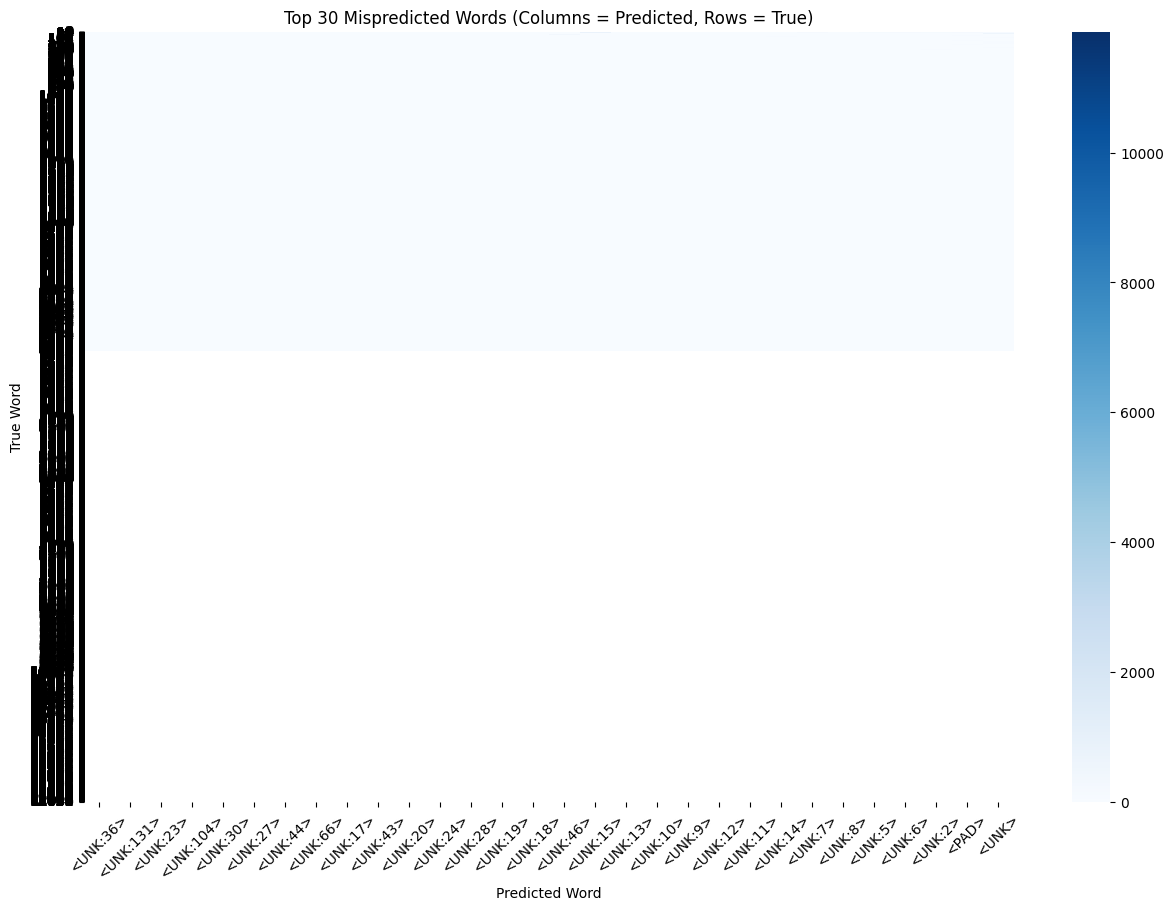

In [122]:
import seaborn as sns

# Extract subset of confusion matrix for top 30
cm_subset = cm[:, top_30_indices]

# Plot
plt.figure(figsize=(15, 10))
sns.heatmap(cm_subset, annot=False, fmt='d', cmap='Blues',
            xticklabels=top_30_words, yticklabels=range(vocab_size))
plt.title('Top 30 Mispredicted Words (Columns = Predicted, Rows = True)')
plt.xlabel('Predicted Word')
plt.ylabel('True Word')
plt.xticks(rotation=45)
plt.show()

In [123]:
for name, param in encoder.named_parameters():
    if 'weight_ih' in name:
        gate_type = name.split('_')[-2][0]  # Extract gate type
        grad_norm = param.grad.norm().item() if param.grad is not None else 0

        if gate_type == 'f':
            gate_gradients['forget'].append(grad_norm)
        elif gate_type == 'i':
            gate_gradients['input'].append(grad_norm)
        elif gate_type == 'o':
            gate_gradients['output'].append(grad_norm)
        elif gate_type == 'c':
            gate_gradients['cell'].append(grad_norm)

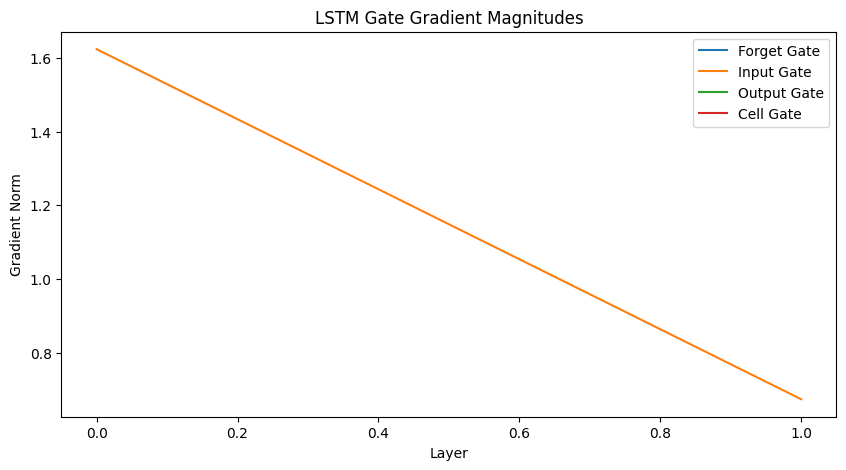

In [124]:
# Plot gradients
plt.figure(figsize=(10, 5))
for gate, grads in gate_gradients.items():
    plt.plot(grads, label=f'{gate.capitalize()} Gate')
plt.title('LSTM Gate Gradient Magnitudes')
plt.xlabel('Layer')
plt.ylabel('Gradient Norm')
plt.legend()
plt.show()

In [125]:
oov_idx = tokenizer.word_index['<UNK>']
oov_targets = sum(1 for t in all_targets if t == oov_idx)
oov_correct = sum(1 for p, t in zip(all_preds, all_targets) if t == oov_idx and p == t)
oov_accuracy = oov_correct / oov_targets if oov_targets > 0 else 0

print(f"\nOOV Analysis:")
print(f"OOV Targets: {oov_targets}")
print(f"OOV Accuracy: {oov_accuracy:.4f}")


OOV Analysis:
OOV Targets: 11573
OOV Accuracy: 0.3003
